## Compare PS snow cover maps to STC-MODSCAG snow cover maps 

Author: Emma Boudreau

In [1]:
from pp_functions import *
from shapely.ops import unary_union
from affine import Affine
import numpy as np

import xarray as xr
import rioxarray
from datetime import datetime
from rasterio.transform import from_origin
from rasterio.enums import Resampling


import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import cmcrameri.cm as cmc
import matplotlib.colors as mcolors
import matplotlib.cm as cm
from mpl_toolkits.axes_grid1 import ImageGrid
from matplotlib.lines import Line2D

In [2]:
# Define Basin, Model Run, Year
name = 'BUDD'
model = 'composite'
year = 2022
starting_value = 0
utm_epsg = 'EPSG:32611'
# utm_epsg = 'EPSG:26913'

# Define filepaths and directories
# mask filepaths
BS = f'/home/etboud/projects/data/basins/{name}/{name}_4326.geojson'
basin_buff_fn = f'/home/etboud/projects/data/masks/{name}_mask_buffered.tif'
basin_fn = f'/home/etboud/projects/data/masks/{name}_mask.tif'
rgi = '/home/etboud/projects/data/RGI/02_rgi60_WesternCanadaUS/02_rgi60_WesternCanadaUS.shp'
wbd = '/home/etboud/projects/data/masks/NHDWaterbody.shp'
can = f'/home/etboud/projects/data/masks/4b_15img_ndvi_30_85_{name}_notclipped.tif'
# raw PS images
ps_raw = f'/data0/images/planet/emma/planet/{name}/'
# Processed PS SCA
ps_sca_dir = f'/data0/images/planet/emma/planet/raw_snow_maps/{name}/{model}/'


# Read in masks
basin = gpd.read_file(BS).to_crs(utm_epsg)
basin_buff_mask = rxr.open_rasterio(basin_buff_fn)
rgi_mask = gpd.read_file(rgi).to_crs(utm_epsg)
wbd_mask = gpd.read_file(wbd).to_crs(utm_epsg)
invalid_area = unary_union(rgi_mask.geometry.values.tolist() + wbd_mask.geometry.values.tolist())
ndvi_mask = rxr.open_rasterio(can)
ndvi_mask.values = np.where(ndvi_mask.values>0, 0, 1)

# Get directories
ps_raw_subdir = sorted([d for d in glob.glob(ps_raw + str(year) + '*') if os.path.isdir(d)])
ps_sca_tif = glob.glob(ps_sca_dir + f'*{year}*.tif')

In [3]:
# Load the reference GeoTIFF with ideal output projection and resolution
with rio.open(f'/home/etboud/projects/data/masks/{name}_mask.tif') as ref:
    ref_crs = ref.crs
    ref_transform = ref.transform
    ref_width = ref.width
    ref_height = ref.height

In [4]:
def reproj_fine_to_coarse(fine_nc,wy):
    coarse_nc = '/data0/images/STC_MODSCG/h08v05/STC_MODSCGDRF_HIST_h08v05_20230401_v01.0.nc'
    fine = xr.open_dataset(fine_nc)
    fine = fine.rio.write_crs('EPSG:32611')
    coarse = xr.open_dataset(coarse_nc)
    coarse = coarse.rio.write_crs(coarse.crs.proj4)
    # Reproject the fine resolution data to match the coarse resolution
    fine_projected = fine.rio.reproject_match(coarse, resampling = Resampling.average)
    # clip bounds to non nan values
    fine = fine_projected.where(~fine_projected.isnull(), drop=True)
    return fine


def read_modis_snowtoday(wy, modis_dir, start_date, end_date, fine):
    

    #mask = ~fine_forced.isnull().any(dim='time')
    
    files = glob.glob(modis_dir + f'*{wy}*nc')
    print(files)
    # select modis file between start and end dates
    dates = [i.split('/')[-1].split('_')[-2] for i in files]
    print(dates)
    files = [files[i] for i, date_str in enumerate(dates)
            if start_date <= pd.to_datetime(date_str) <= end_date]
    files.sort()
    ds_list = []
    print(files)
    sca_list = []
    for f in files[0:]:
        ds = xr.open_dataset(f,engine='netcdf4')
        ds = ds.rio.write_crs(ds.crs.proj4)
        modis_sca = ds['snow_fraction']
        # # Clip coarse to fine_reprojected extent (matching coordinates)
        modis_sca = modis_sca.rio.clip_box(*fine.rio.bounds())
        

        date_str = f.split('/')[-1].split('_')[-2]
        date = pd.to_datetime(date_str)
        
        modis_sca = modis_sca.assign_coords(time=('time', [date]))        

        sca_list.append(modis_sca)

    proj4_str = ds.rio.crs
    combine_ds_sca = xr.concat(sca_list, dim='time')
    combine_ds_sca.rio.write_crs(proj4_str, inplace=True)

    mask = ~fine.isnull().any(dim='time')
    combine_ds_sca = combine_ds_sca.where(mask)  
    combine_ds_sca = combine_ds_sca/100
    return combine_ds_sca 

def create_fsca_df(dataset):
    sca_df = []
    for t in range(len(dataset.time)):
        slice = dataset['data'].isel(time=t)
        fsca = (np.nansum(slice) / np.count_nonzero(~np.isnan(slice)))*100
        if fsca> 100:
            fsca = 100
        sca_df.append(fsca)    
    #create dataframe with fsca_list and corresponding dates
    dates = pd.to_datetime(dataset.time.values)
    df = pd.DataFrame({'date': dates, 'fsca': sca_df})
    return df



In [5]:
from rasterio.enums import Resampling

def get_fsca_df(fine_nc,wy, modis_dir, start_date, end_date):
    aso = reproj_fine_to_coarse(f'/home/etboud/projects/data/stacks/extra/BUDD_aso_projected.nc', wy)
    fine = reproj_fine_to_coarse(fine_nc, wy)
    modis_sca_ds = read_modis_snowtoday(
        wy=wateryear,
        modis_dir=modis_dir,
        start_date=start_date,
        end_date=end_date,
        fine=fine
    ) 

    modis_df = create_fsca_df(modis_sca_ds)
    planet_df = create_fsca_df(fine)
    aso_df = create_fsca_df(aso)
    # merge modis oon ps dates
    modis_df['date'] = pd.to_datetime(modis_df['date'])
    planet_df['date'] = pd.to_datetime(planet_df['date'])
    aso_df['date'] = pd.to_datetime(aso_df['date'])
    ps_merged_df = pd.merge(modis_df, planet_df, on='date', suffixes=('_modis', '_ps'))
    aso_merged_df = pd.merge(modis_df, aso_df, on='date', suffixes=('_modis', '_aso'))
    return ps_merged_df, aso_merged_df,modis_sca_ds, fine

In [ ]:
name = 'BUDD'
wateryears = [2020, 2022, 2023]

filename_templates = [
    '{name}_base_{wateryear}_projected.nc',                   # merged_1
    '{name}_baseST_{wateryear}_3_30.nc',                      # merged_2
    '{name}_composite_{wateryear}_projected.nc',              # merged_3
    '{name}_compositeT_{wateryear}_QAQC_temporal.nc'          # merged_4
]

def day_of_season(date):
    dummy_year = 2001
    season_start = pd.Timestamp(f"{dummy_year}-04-01")
    current = pd.Timestamp(f"{dummy_year}-{date.month:02d}-{date.day:02d}")
    return (current - season_start).days

# Automate loading and assign to individual variables
for i, template in enumerate(filename_templates, start=1):
    ps_merged_list = []
    aso_merged_list = []
    for wateryear in wateryears:
        fine_nc = f'/home/etboud/projects/data/stacks/sep/{template.format(name=name, wateryear=wateryear)}'
        modis_dir = '/data0/images/STC_MODSCG/h08v05/'
        start_date = pd.to_datetime(f'{wateryear}-04-01')
        end_date = pd.to_datetime(f'{wateryear + 1}-09-30')

        ps_df, aso_df, modis_sca_ds, fine = get_fsca_df(fine_nc, wateryear, modis_dir, start_date, end_date)

        ps_merged_list.append(ps_df)
        aso_merged_list.append(aso_df)

    ps_merged_df_all = pd.concat(ps_merged_list, ignore_index=True)
    aso_merged_df_all = pd.concat(aso_merged_list, ignore_index=True)

    ps_merged_df_all['day_of_season'] = ps_merged_df_all['date'].apply(day_of_season)
    aso_merged_df_all['day_of_season'] = aso_merged_df_all['date'].apply(day_of_season)

    # Dynamically create variable like merged_1, merged_2, ...
    globals()[f'merged_{i}'] = ps_merged_df_all

# multiple years, single model

In [ ]:
name = 'BUDD'
ps_merged_list = []
aso_merged_list = []
for wateryear in [2020,2022,2023]:
    fine_nc = f'/home/etboud/projects/data/stacks/sep/{name}_base_{wateryear}_projected.nc'
    # fine_nc= f'/home/etboud/projects/data/stacks/sep/{name}_baseST_{wateryear}_3_30.nc'
    # fine_nc = f'/home/etboud/projects/data/stacks/sep/{name}_composite_{wateryear}_projected.nc'
    # fine_nc = f'/home/etboud/projects/data/stacks/sep/{name}_compositeT_{wateryear}_QAQC_temporal.nc'
    modis_dir = '/data0/images/STC_MODSCG/h08v05/'
    start_date = pd.to_datetime(f'{wateryear}-04-01')
    end_date = pd.to_datetime(f'{wateryear+1}-09-30')
    ps_df, aso_df,modis_sca_ds,fine= get_fsca_df(fine_nc, wateryear, modis_dir, start_date, end_date)
    
    ps_merged_list.append(ps_df)
    aso_merged_list.append(aso_df)

ps_merged_df_all = pd.concat(ps_merged_list, ignore_index=True)
aso_merged_df_all = pd.concat(aso_merged_list, ignore_index=True)
def day_of_season(date):
    dummy_year = 2001
    season_start = pd.Timestamp(f"{dummy_year}-04-01")
    current = pd.Timestamp(f"{dummy_year}-{date.month:02d}-{date.day:02d}")
    return (current - season_start).days

ps_merged_df_all['day_of_season'] = ps_merged_df_all['date'].apply(day_of_season)
aso_merged_df_all['day_of_season'] = aso_merged_df_all['date'].apply(day_of_season)

['/data0/images/STC_MODSCG/h08v05/STC_MODSCGDRF_HIST_h08v05_20200511_v01.0.nc', '/data0/images/STC_MODSCG/h08v05/STC_MODSCGDRF_HIST_h08v05_20200116_v01.0.nc', '/data0/images/STC_MODSCG/h08v05/STC_MODSCGDRF_HIST_h08v05_20200715_v01.0.nc', '/data0/images/STC_MODSCG/h08v05/STC_MODSCGDRF_HIST_h08v05_20200424_v01.0.nc', '/data0/images/STC_MODSCG/h08v05/STC_MODSCGDRF_HIST_h08v05_20200824_v01.0.nc', '/data0/images/STC_MODSCG/h08v05/STC_MODSCGDRF_HIST_h08v05_20200930_v01.0.nc', '/data0/images/STC_MODSCG/h08v05/STC_MODSCGDRF_HIST_h08v05_20201228_v01.0.nc', '/data0/images/STC_MODSCG/h08v05/STC_MODSCGDRF_HIST_h08v05_20201016_v01.0.nc', '/data0/images/STC_MODSCG/h08v05/STC_MODSCGDRF_HIST_h08v05_20200405_v01.0.nc', '/data0/images/STC_MODSCG/h08v05/STC_MODSCGDRF_HIST_h08v05_20201106_v01.0.nc', '/data0/images/STC_MODSCG/h08v05/STC_MODSCGDRF_HIST_h08v05_20200711_v01.0.nc', '/data0/images/STC_MODSCG/h08v05/STC_MODSCGDRF_HIST_h08v05_20200320_v01.0.nc', '/data0/images/STC_MODSCG/h08v05/STC_MODSCGDRF_HIST

In [ ]:
# merged_1 = ps_merged_df_all
# #merged_1 = base
# #merged_2 = base spatial+ temporal
# #merged_3 comp
# #merged_4 = comp spatial + temporal

In [ ]:
aso_merged = aso_merged_df_all
modis_df = merged_1
modis_df = modis_df.rename(columns={'fsca_modis': 'fsca', 'fsca_ps': 'fsca_ps'})

# Figures

### Timeseries figure with inset 

/tmp/ipykernel_1274292/2631207698.py:119: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


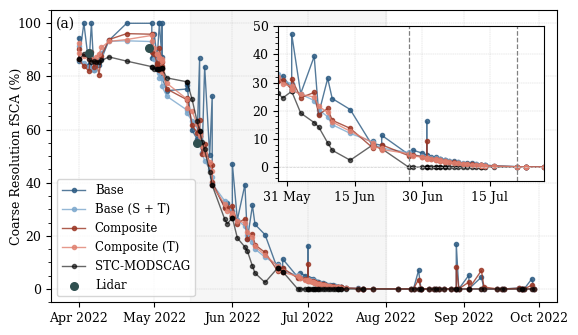

In [57]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.lines import Line2D
import matplotlib.ticker as tck

# === Setup ===
n_total = 11
n_colors = 6
plt.rcParams['font.family'] = 'serif'
year = '2022'

# Custom colors
colors = ['#2a5981', '#7ba7cc', '#9a3422', '#e0806f']
dfs = [merged_1, merged_2, merged_3, merged_4]
names = ['Base', 'Base (S + T)', 'Composite', 'Composite (T)']

# Define date ranges
start_date = pd.to_datetime(f'{year}-03-31')
end_date = pd.to_datetime(f'{year}-09-30')
inset_start = pd.to_datetime(f'{year}-05-25')
inset_end = pd.to_datetime(f'{year}-08-01')

# Trim main MODIS data
trimmed_modis_df = modis_df[(modis_df['date'] >= start_date) & (modis_df['date'] <= end_date)]

# === Scaling for journal submission ===
scale = 7/12  # target width / current width
fig_width, fig_height = 5.9, 3.45

fs_label = 9 
fs_tick  = 9
fs_text  = 10
fs_legend = 8.5
ms_marker = 3
lw_line = 1
s_scatter = 30 

# === Main Figure ===
fig, ax = plt.subplots(figsize=(fig_width, fig_height))

# Main time series
for i, df in enumerate(dfs):
    trimmed_df = df[(df['date'] >= start_date) & (df['date'] <= end_date)]
    ax.plot(trimmed_df['date'], trimmed_df['fsca_ps'], label=names[i],
            marker='o', markersize=ms_marker, linestyle='-', linewidth=lw_line,
            color=colors[i], alpha=.8)

# MODIS
ax.plot(trimmed_modis_df['date'], trimmed_modis_df['fsca'], label='STC-MODSCAG',
        marker='o', markersize=ms_marker, linestyle='-', linewidth=lw_line,
        color='black', alpha=.6)

# ASO
ax.scatter(aso_merged_df_all['date'], aso_merged_df_all['fsca_aso'], label='Lidar',
           color='darkslategrey', s=s_scatter, zorder=10)

# === Inset ===
ax_inset = fig.add_axes([0.48, 0.46, 0.45, 0.45])

# Trim and plot inset datasets
trimmed_modis_inset = modis_df[(modis_df['date'] >= inset_start) & (modis_df['date'] <= inset_end)].dropna(subset=['fsca'])
trimmed_aso_inset = aso_merged_df_all[(aso_merged_df_all['date'] >= inset_start) & (aso_merged_df_all['date'] <= inset_end)].dropna(subset=['fsca_aso'])

# Inset plots
ax_inset.plot(trimmed_aso_inset['date'], trimmed_aso_inset['fsca_aso'], label='Lidar',
              color='darkslategrey', linewidth=lw_line)
ax_inset.plot(trimmed_modis_inset['date'], trimmed_modis_inset['fsca'], label='STC-MODSCAG',
              marker='o', markersize=ms_marker, linewidth=lw_line, color='black', alpha=0.6)

for i, df in enumerate(dfs):
    trimmed_df = df[(df['date'] >= inset_start) & (df['date'] <= inset_end)].dropna(subset=['fsca_ps'])
    ax_inset.plot(trimmed_df['date'], trimmed_df['fsca_ps'], label=names[i],
                  marker='o', markersize=ms_marker, linestyle='-', linewidth=lw_line,
                  color=colors[i], alpha=0.8)

# Inset styling
ax_inset.axvline(pd.to_datetime(f'{year}-06-27'), color='gray', linestyle='--', linewidth=0.9)
ax_inset.axvline(pd.to_datetime(f'{year}-07-21'), color='gray', linestyle='--', linewidth=0.9)
ax_inset.axhline(0, color='lightgray', linestyle='--', linewidth=0.5)

ax_inset.set_ylim(-5, 50)
ax_inset.xaxis.set_major_locator(mdates.DayLocator(interval=15))
ax_inset.xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))
ax_inset.yaxis.set_minor_locator(tck.AutoMinorLocator())
ax_inset.grid(True, which='major', linestyle='--', linewidth=0.3, color='gray', alpha=0.4)
ax_inset.tick_params(axis='x', labelsize=fs_tick)
ax_inset.tick_params(axis='y', labelsize=fs_tick)
# Get exact min/max of the dates for the inset
x_min = min(trimmed_modis_inset['date'].min(),
            trimmed_aso_inset['date'].min(),
            min([df[(df['date'] >= inset_start) & (df['date'] <= inset_end)]['date'].min() for df in dfs]))

x_max = max(trimmed_modis_inset['date'].max(),
            trimmed_aso_inset['date'].max(),
            max([df[(df['date'] >= inset_start) & (df['date'] <= inset_end)]['date'].max() for df in dfs]))

ax_inset.set_xlim(x_min, x_max)
# === Main Plot Styling ===
ax.set_xlim(pd.to_datetime(f'{year}-03-21'), pd.to_datetime(f'{year}-10-08'))
ax.set_ylim(-5, 105)
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.yaxis.set_minor_locator(tck.AutoMinorLocator())
ax.grid(True, which='major', linestyle='--', linewidth=0.3, color='gray', alpha=0.4)
ax.tick_params(axis='x', labelsize=fs_tick)
ax.tick_params(axis='y', labelsize=fs_tick)
ax.axvspan(pd.to_datetime(f'{year}-05-15'), pd.to_datetime(f'{year}-08-01'), color='lightgray', alpha=0.2)
ax.set_ylabel('Coarse Resolution fSCA (%)', fontsize=fs_label, labelpad=-4)
ax.text(0.01, 0.94, '(a)', transform=ax.transAxes, fontsize=fs_text)


# === Legend ===
custom_lines = [Line2D([0], [0], color=colors[i], lw=lw_line) for i in range(len(names))] + [
    Line2D([0], [0], marker='o', color='darkslategrey', lw=0, markersize=2, label='ASO')]
ax.legend(custom_lines, names + ['ASO'], loc='lower left', fontsize=fs_legend)
ax.legend(loc='lower left', fontsize=fs_legend)
# === Finalize ===
plt.tight_layout()
# plt.show()# Save PDF for submission
plt.savefig('/home/etboud/projects/figures/Figure_6_bigger.png', format='png',dpi = 1000,bbox_inches='tight')

/tmp/ipykernel_1171165/717072457.py:84: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


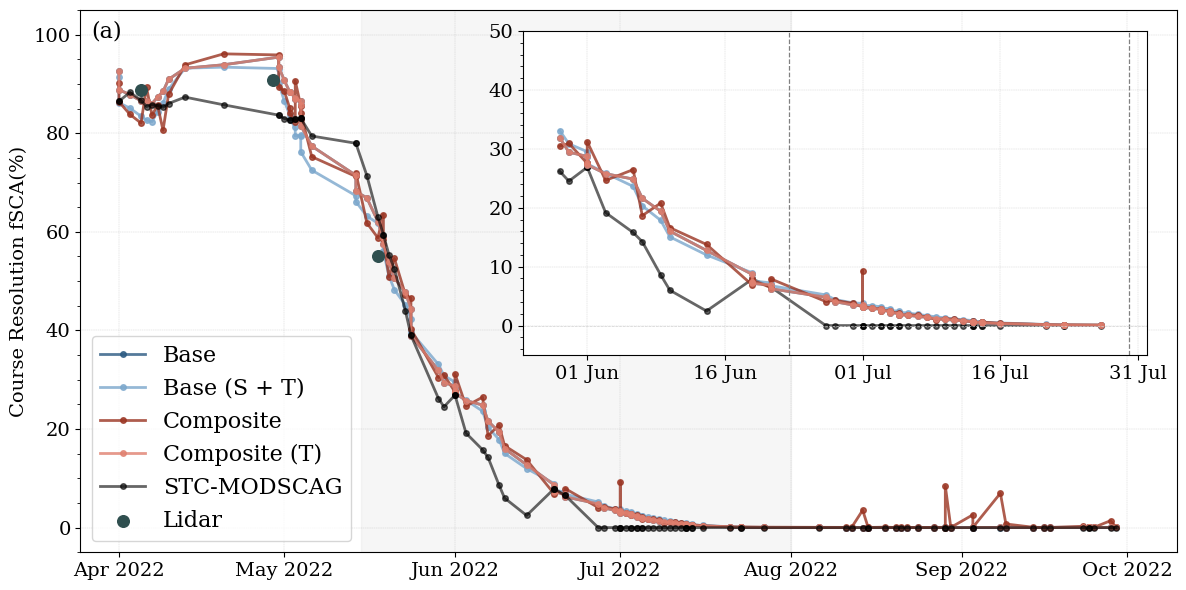

In [45]:
# === Setup ===
n_total = 11
n_colors = 6
plt.rcParams['font.family'] = 'serif'
year = '2022'

# Custom colors
colors = ['#2a5981', '#7ba7cc', '#9a3422', '#e0806f']
dfs = [merged_1, merged_2, merged_3, merged_4]
names = ['Base', 'Base (S + T)', 'Composite', 'Composite (T)']

# Define date ranges
start_date = pd.to_datetime(f'{year}-04-01')
end_date = pd.to_datetime(f'{year}-09-30')
inset_start = pd.to_datetime(f'{year}-05-25')
inset_end = pd.to_datetime(f'{year}-08-01')

# Trim main MODIS data
trimmed_modis_df = modis_df[(modis_df['date'] >= start_date) & (modis_df['date'] <= end_date)]

# === Main Figure ===
fig, ax = plt.subplots(figsize=(12, 6))

# Main time series
for i, df in enumerate(dfs):
    trimmed_df = df[(df['date'] >= start_date) & (df['date'] <= end_date)]
    ax.plot(trimmed_df['date'], trimmed_df['fsca_ps'], label=names[i], marker='o', markersize=4,
            linestyle='-', linewidth=2, color=colors[i], alpha=.8)

ax.plot(trimmed_modis_df['date'], trimmed_modis_df['fsca'], label='STC-MODSCAG', marker='o', markersize=4,
        linestyle='-', linewidth=2, color='black', alpha=.6)
ax.scatter(aso_merged_df_all['date'], aso_merged_df_all['fsca_aso'], label='Lidar',
           color='darkslategrey', s=70, zorder=10)

# === Inset ===
ax_inset = fig.add_axes([0.44, 0.40, 0.52, 0.54])

# Trim and plot inset datasets
trimmed_modis_inset = modis_df[(modis_df['date'] >= inset_start) & (modis_df['date'] <= inset_end)].dropna(subset=['fsca'])
trimmed_aso_inset = aso_merged_df_all[(aso_merged_df_all['date'] >= inset_start) & (aso_merged_df_all['date'] <= inset_end)].dropna(subset=['fsca_aso'])

# Inset plots
ax_inset.plot(trimmed_aso_inset['date'], trimmed_aso_inset['fsca_aso'], label='Lidar', color='darkslategrey')
ax_inset.plot(trimmed_modis_inset['date'], trimmed_modis_inset['fsca'], label='STC-MODSCAG',
              marker='o', markersize=4, linewidth=2, color='black', alpha=0.6)

for i, df in enumerate(dfs):
    trimmed_df = df[(df['date'] >= inset_start) & (df['date'] <= inset_end)].dropna(subset=['fsca_ps'])
    ax_inset.plot(trimmed_df['date'], trimmed_df['fsca_ps'], label=names[i], marker='o', markersize=4,
                  linestyle='-', linewidth=2, color=colors[i], alpha=0.8)

# Inset styling
ax_inset.axvline(pd.to_datetime(f'{year}-06-23'), color='gray', linestyle='--', linewidth=0.9)
ax_inset.axvline(pd.to_datetime(f'{year}-07-30'), color='gray', linestyle='--', linewidth=0.9)
ax_inset.axhline(0, color='lightgray', linestyle='--', linewidth=0.5)
ax_inset.set_xlim(inset_start, inset_end)
ax_inset.set_ylim(-5, 50)
ax_inset.xaxis.set_major_locator(mdates.DayLocator(interval=15))
ax_inset.xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))
ax_inset.yaxis.set_minor_locator(tck.AutoMinorLocator())
ax_inset.grid(True, which='major', linestyle='--', linewidth=0.3, color='gray', alpha=0.4)
ax_inset.tick_params(axis='x', labelsize=14)
ax_inset.tick_params(axis='y', labelsize=14)

# === Main Plot Styling ===
ax.set_xlim(pd.to_datetime(f'{year}-03-25'), pd.to_datetime(f'{year}-10-10'))
ax.set_ylim(-5, 105)
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.yaxis.set_minor_locator(tck.AutoMinorLocator())
ax.grid(True, which='major', linestyle='--', linewidth=0.3, color='gray', alpha=0.4)
ax.tick_params(axis='x', labelsize=14)
ax.tick_params(axis='y', labelsize=14)
ax.axvspan(pd.to_datetime(f'{year}-05-15'), pd.to_datetime(f'{year}-08-01'), color='lightgray', alpha=0.2)
ax.set_ylabel('Course Resolution fSCA(%)', fontsize=14)
ax.text(0.01, 0.95, f'(a)', transform=ax.transAxes, fontsize=16)

# === Legend ===
custom_lines = [Line2D([0], [0], color=colors[i], lw=2) for i in range(len(names))] + [
    Line2D([0], [0], marker='o', color='darkslategrey', label='ASO')]
ax.legend(custom_lines, names[:len(custom_lines)], loc='lower left', fontsize=16)
ax.legend(loc='lower left', fontsize=16)
# === Finalize ===
plt.tight_layout()
plt.show()

/tmp/ipykernel_854497/4096058384.py:84: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


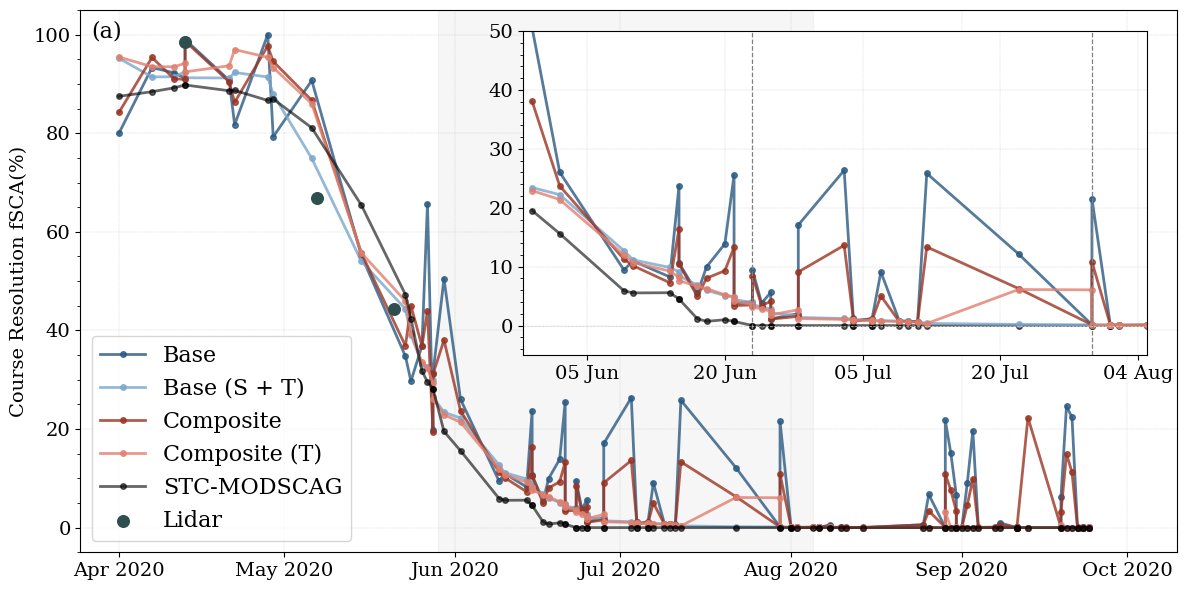

In [ ]:
# === Setup ===
n_total = 11
n_colors = 6
plt.rcParams['font.family'] = 'serif'
year = '2020'

# Custom colors
colors = ['#2a5981', '#7ba7cc', '#9a3422', '#e0806f']
dfs = [merged_1, merged_2, merged_3, merged_4]
names = ['Base', 'Base (S + T)', 'Composite', 'Composite (T)']

# Define date ranges
start_date = pd.to_datetime(f'{year}-04-01')
end_date = pd.to_datetime(f'{year}-09-30')
inset_start = pd.to_datetime(f'{year}-05-29')
inset_end = pd.to_datetime(f'{year}-08-05')

# Trim main MODIS data
trimmed_modis_df = modis_df[(modis_df['date'] >= start_date) & (modis_df['date'] <= end_date)]

# === Main Figure ===
fig, ax = plt.subplots(figsize=(12, 6))

# Main time series
for i, df in enumerate(dfs):
    trimmed_df = df[(df['date'] >= start_date) & (df['date'] <= end_date)]
    ax.plot(trimmed_df['date'], trimmed_df['fsca_ps'], label=names[i], marker='o', markersize=4,
            linestyle='-', linewidth=2, color=colors[i], alpha=.8)

ax.plot(trimmed_modis_df['date'], trimmed_modis_df['fsca'], label='STC-MODSCAG', marker='o', markersize=4,
        linestyle='-', linewidth=2, color='black', alpha=.6)
ax.scatter(aso_merged_df_all['date'], aso_merged_df_all['fsca_aso'], label='Lidar',
           color='darkslategrey', s=70, zorder=10)

# === Inset ===
ax_inset = fig.add_axes([0.44, 0.40, 0.52, 0.54])

# Trim and plot inset datasets
trimmed_modis_inset = modis_df[(modis_df['date'] >= inset_start) & (modis_df['date'] <= inset_end)].dropna(subset=['fsca'])
trimmed_aso_inset = aso_merged_df_all[(aso_merged_df_all['date'] >= inset_start) & (aso_merged_df_all['date'] <= inset_end)].dropna(subset=['fsca_aso'])

# Inset plots
ax_inset.plot(trimmed_aso_inset['date'], trimmed_aso_inset['fsca_aso'], label='Lidar', color='darkslategrey')
ax_inset.plot(trimmed_modis_inset['date'], trimmed_modis_inset['fsca'], label='STC-MODSCAG',
              marker='o', markersize=4, linewidth=2, color='black', alpha=0.6)

for i, df in enumerate(dfs):
    trimmed_df = df[(df['date'] >= inset_start) & (df['date'] <= inset_end)].dropna(subset=['fsca_ps'])
    ax_inset.plot(trimmed_df['date'], trimmed_df['fsca_ps'], label=names[i], marker='o', markersize=4,
                  linestyle='-', linewidth=2, color=colors[i], alpha=0.8)

# Inset styling
ax_inset.axvline(pd.to_datetime(f'{year}-06-23'), color='gray', linestyle='--', linewidth=0.9)
ax_inset.axvline(pd.to_datetime(f'{year}-07-30'), color='gray', linestyle='--', linewidth=0.9)
ax_inset.axhline(0, color='lightgray', linestyle='--', linewidth=0.5)
ax_inset.set_xlim(inset_start, inset_end)
ax_inset.set_ylim(-5, 50)
ax_inset.xaxis.set_major_locator(mdates.DayLocator(interval=15))
ax_inset.xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))
ax_inset.yaxis.set_minor_locator(tck.AutoMinorLocator())
ax_inset.grid(True, which='major', linestyle='--', linewidth=0.3, color='gray', alpha=0.4)
ax_inset.tick_params(axis='x', labelsize=14)
ax_inset.tick_params(axis='y', labelsize=14)

# === Main Plot Styling ===
ax.set_xlim(pd.to_datetime(f'{year}-03-25'), pd.to_datetime(f'{year}-10-10'))
ax.set_ylim(-5, 105)
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.yaxis.set_minor_locator(tck.AutoMinorLocator())
ax.grid(True, which='major', linestyle='--', linewidth=0.3, color='gray', alpha=0.4)
ax.tick_params(axis='x', labelsize=14)
ax.tick_params(axis='y', labelsize=14)
ax.axvspan(pd.to_datetime(inset_start), pd.to_datetime(inset_end), color='lightgray', alpha=0.2)
ax.set_ylabel('Course Resolution fSCA(%)', fontsize=14)
ax.text(0.01, 0.95, f'(a)', transform=ax.transAxes, fontsize=16)

# === Legend ===
custom_lines = [Line2D([0], [0], color=colors[i], lw=2) for i in range(len(names))] + [
    Line2D([0], [0], marker='o', color='darkslategrey', label='ASO')]
ax.legend(custom_lines, names[:len(custom_lines)], loc='lower left', fontsize=16)
ax.legend(loc='lower left', fontsize=16)
# === Finalize ===
plt.tight_layout()
# plt.show()
# plt.savefig(f'/home/etboud/projects/figures/BUDD_fsca_timeseries_{year}_colors_dark.png', dpi=400, bbox_inches='tight')

/tmp/ipykernel_1274292/2151162021.py:118: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


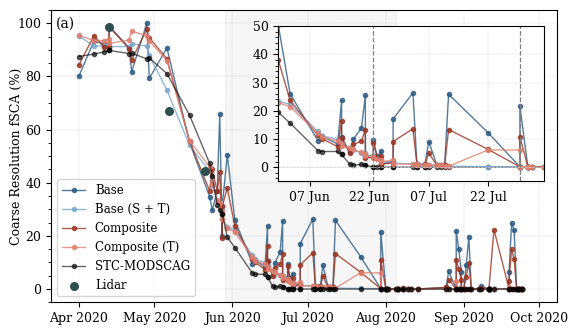

In [69]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.lines import Line2D
import matplotlib.ticker as tck

# === Setup ===
n_total = 11
n_colors = 6
plt.rcParams['font.family'] = 'serif'
year = '2020'

# Custom colors
colors = ['#2a5981', '#7ba7cc', '#9a3422', '#e0806f']
dfs = [merged_1, merged_2, merged_3, merged_4]
names = ['Base', 'Base (S + T)', 'Composite', 'Composite (T)']

# Define date ranges
start_date = pd.to_datetime(f'{year}-04-01')
end_date = pd.to_datetime(f'{year}-09-30')
inset_start = pd.to_datetime(f'{year}-05-29')
inset_end = pd.to_datetime(f'{year}-08-05')
# Trim main MODIS data
trimmed_modis_df = modis_df[(modis_df['date'] >= start_date) & (modis_df['date'] <= end_date)]

# === Scaling for journal submission ===
scale = 7/12  # target width / current width
fig_width, fig_height = 5.9, 3.45

fs_label = 9 
fs_tick  = 9
fs_text  = 10
fs_legend = 8.5
ms_marker = 3
lw_line = 1
s_scatter = 30 

# === Main Figure ===
fig, ax = plt.subplots(figsize=(fig_width, fig_height))

# Main time series
for i, df in enumerate(dfs):
    trimmed_df = df[(df['date'] >= start_date) & (df['date'] <= end_date)]
    ax.plot(trimmed_df['date'], trimmed_df['fsca_ps'], label=names[i],
            marker='o', markersize=ms_marker, linestyle='-', linewidth=lw_line,
            color=colors[i], alpha=.8)

# MODIS
ax.plot(trimmed_modis_df['date'], trimmed_modis_df['fsca'], label='STC-MODSCAG',
        marker='o', markersize=ms_marker, linestyle='-', linewidth=lw_line,
        color='black', alpha=.6)

# ASO
ax.scatter(aso_merged_df_all['date'], aso_merged_df_all['fsca_aso'], label='Lidar',
           color='darkslategrey', s=s_scatter, zorder=10)

# === Inset ===
ax_inset = fig.add_axes([0.48, 0.46, 0.45, 0.45])

# Trim and plot inset datasets
trimmed_modis_inset = modis_df[(modis_df['date'] >= inset_start) & (modis_df['date'] <= inset_end)].dropna(subset=['fsca'])
trimmed_aso_inset = aso_merged_df_all[(aso_merged_df_all['date'] >= inset_start) & (aso_merged_df_all['date'] <= inset_end)].dropna(subset=['fsca_aso'])

# Inset plots
ax_inset.plot(trimmed_aso_inset['date'], trimmed_aso_inset['fsca_aso'], label='Lidar',
              color='darkslategrey', linewidth=lw_line)
ax_inset.plot(trimmed_modis_inset['date'], trimmed_modis_inset['fsca'], label='STC-MODSCAG',
              marker='o', markersize=ms_marker, linewidth=lw_line, color='black', alpha=0.6)

for i, df in enumerate(dfs):
    trimmed_df = df[(df['date'] >= inset_start) & (df['date'] <= inset_end)].dropna(subset=['fsca_ps'])
    ax_inset.plot(trimmed_df['date'], trimmed_df['fsca_ps'], label=names[i],
                  marker='o', markersize=ms_marker, linestyle='-', linewidth=lw_line,
                  color=colors[i], alpha=0.8)

# Inset styling
ax_inset.axvline(pd.to_datetime(f'{year}-06-23'), color='gray', linestyle='--', linewidth=0.9)
ax_inset.axvline(pd.to_datetime(f'{year}-07-30'), color='gray', linestyle='--', linewidth=0.9)
ax_inset.axhline(0, color='lightgray', linestyle='--', linewidth=0.5)

ax_inset.set_ylim(-5, 50)
ax_inset.xaxis.set_major_locator(mdates.DayLocator(interval=15))
ax_inset.xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))
ax_inset.yaxis.set_minor_locator(tck.AutoMinorLocator())
ax_inset.grid(True, which='major', linestyle='--', linewidth=0.3, color='gray', alpha=0.4)
ax_inset.tick_params(axis='x', labelsize=fs_tick)
ax_inset.tick_params(axis='y', labelsize=fs_tick)
# Get exact min/max of the dates for the inset
x_min = min(trimmed_modis_inset['date'].min(),
            trimmed_aso_inset['date'].min(),
            min([df[(df['date'] >= inset_start) & (df['date'] <= inset_end)]['date'].min() for df in dfs]))

x_max = max(trimmed_modis_inset['date'].max(),
            trimmed_aso_inset['date'].max(),
            max([df[(df['date'] >= inset_start) & (df['date'] <= inset_end)]['date'].max() for df in dfs]))

ax_inset.set_xlim(x_min, x_max)
# === Main Plot Styling ===
ax.set_xlim(pd.to_datetime(f'{year}-03-21'), pd.to_datetime(f'{year}-10-08'))
ax.set_ylim(-5, 105)
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.yaxis.set_minor_locator(tck.AutoMinorLocator())
ax.grid(True, which='major', linestyle='--', linewidth=0.3, color='gray', alpha=0.4)
ax.tick_params(axis='x', labelsize=fs_tick)
ax.tick_params(axis='y', labelsize=fs_tick)
ax.axvspan(pd.to_datetime(inset_start), pd.to_datetime(inset_end), color='lightgray', alpha=0.2)
ax.set_ylabel('Coarse Resolution fSCA (%)', fontsize=fs_label, labelpad=-4)
ax.text(0.01, 0.94, '(a)', transform=ax.transAxes, fontsize=fs_text)


# === Legend ===
custom_lines = [Line2D([0], [0], color=colors[i], lw=lw_line) for i in range(len(names))] + [
    Line2D([0], [0], marker='o', color='darkslategrey', lw=0, markersize=2, label='ASO')]
ax.legend(custom_lines, names + ['ASO'], loc='lower left', fontsize=fs_legend)
ax.legend(loc='lower left', fontsize=fs_legend)
# === Finalize ===
plt.tight_layout()
# plt.show()# Save PDF for submission
plt.savefig('/home/etboud/projects/figures/Figure_S4.png', format='png',dpi = 1000,bbox_inches='tight')

/tmp/ipykernel_854497/3425705618.py:84: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


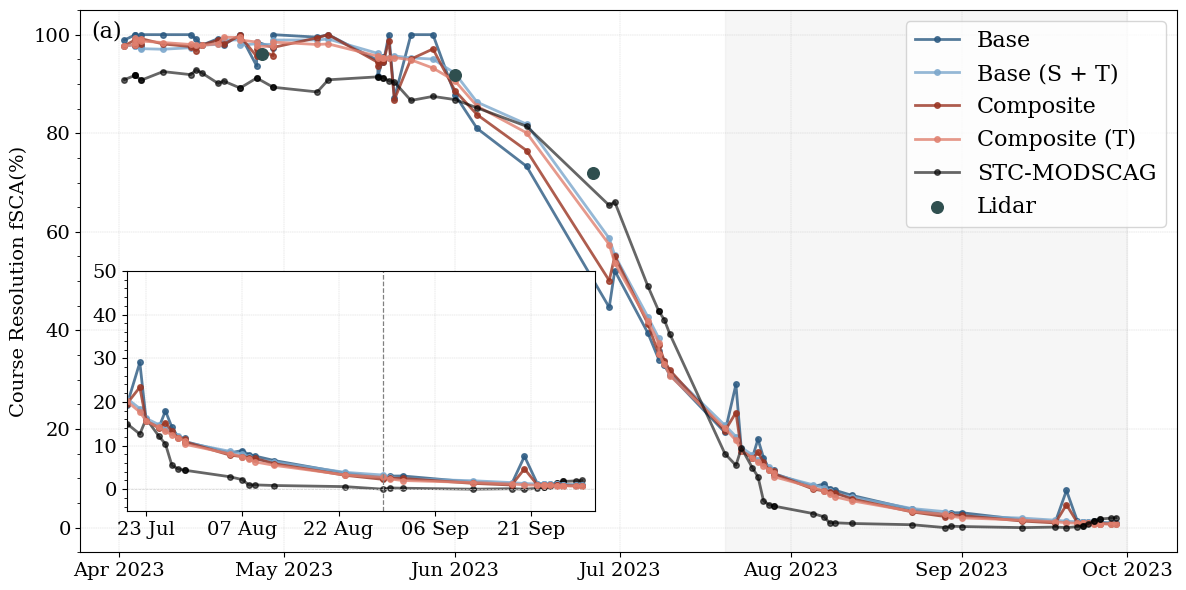

In [35]:
# === Setup ===
n_total = 11
n_colors = 6
plt.rcParams['font.family'] = 'serif'
year = '2023'

# Custom colors
colors = ['#2a5981', '#7ba7cc', '#9a3422', '#e0806f']
dfs = [merged_1, merged_2, merged_3, merged_4]
names = ['Base', 'Base (S + T)', 'Composite', 'Composite (T)']

# Define date ranges
start_date = pd.to_datetime(f'{year}-04-01')
end_date = pd.to_datetime(f'{year}-09-30')
inset_start = pd.to_datetime(f'{year}-07-20')
inset_end = pd.to_datetime(f'{year}-10-01')

# Trim main MODIS data
trimmed_modis_df = modis_df[(modis_df['date'] >= start_date) & (modis_df['date'] <= end_date)]

# === Main Figure ===
fig, ax = plt.subplots(figsize=(12, 6))

# Main time series
for i, df in enumerate(dfs):
    trimmed_df = df[(df['date'] >= start_date) & (df['date'] <= end_date)]
    ax.plot(trimmed_df['date'], trimmed_df['fsca_ps'], label=names[i], marker='o', markersize=4,
            linestyle='-', linewidth=2, color=colors[i], alpha=.8)

ax.plot(trimmed_modis_df['date'], trimmed_modis_df['fsca'], label='STC-MODSCAG', marker='o', markersize=4,
        linestyle='-', linewidth=2, color='black', alpha=.6)
ax.scatter(aso_merged_df_all['date'], aso_merged_df_all['fsca_aso'], label='Lidar',
           color='darkslategrey', s=70, zorder=10)

# === Inset ===
ax_inset = fig.add_axes([0.11, 0.14, 0.39, 0.4])

# Trim and plot inset datasets
trimmed_modis_inset = modis_df[(modis_df['date'] >= inset_start) & (modis_df['date'] <= inset_end)].dropna(subset=['fsca'])
trimmed_aso_inset = aso_merged_df_all[(aso_merged_df_all['date'] >= inset_start) & (aso_merged_df_all['date'] <= inset_end)].dropna(subset=['fsca_aso'])

# Inset plots
ax_inset.plot(trimmed_aso_inset['date'], trimmed_aso_inset['fsca_aso'], label='Lidar', color='darkslategrey')
ax_inset.plot(trimmed_modis_inset['date'], trimmed_modis_inset['fsca'], label='STC-MODSCAG',
              marker='o', markersize=4, linewidth=2, color='black', alpha=0.6)

for i, df in enumerate(dfs):
    trimmed_df = df[(df['date'] >= inset_start) & (df['date'] <= inset_end)].dropna(subset=['fsca_ps'])
    ax_inset.plot(trimmed_df['date'], trimmed_df['fsca_ps'], label=names[i], marker='o', markersize=4,
                  linestyle='-', linewidth=2, color=colors[i], alpha=0.8)

# Inset styling
ax_inset.axvline(pd.to_datetime(f'{year}-06-27'), color='gray', linestyle='--', linewidth=0.9)
ax_inset.axvline(pd.to_datetime(f'{year}-08-29'), color='gray', linestyle='--', linewidth=0.9)
ax_inset.axhline(0, color='lightgray', linestyle='--', linewidth=0.5)
ax_inset.set_xlim(inset_start, inset_end)
ax_inset.set_ylim(-5, 50)
ax_inset.xaxis.set_major_locator(mdates.DayLocator(interval=15))
ax_inset.xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))
ax_inset.yaxis.set_minor_locator(tck.AutoMinorLocator())
ax_inset.grid(True, which='major', linestyle='--', linewidth=0.3, color='gray', alpha=0.4)
ax_inset.tick_params(axis='x', labelsize=14)
ax_inset.tick_params(axis='y', labelsize=14)

# === Main Plot Styling ===
ax.set_xlim(pd.to_datetime(f'{year}-03-25'), pd.to_datetime(f'{year}-10-10'))
ax.set_ylim(-5, 105)
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.yaxis.set_minor_locator(tck.AutoMinorLocator())
ax.grid(True, which='major', linestyle='--', linewidth=0.3, color='gray', alpha=0.4)
ax.tick_params(axis='x', labelsize=14)
ax.tick_params(axis='y', labelsize=14)
ax.axvspan(pd.to_datetime(inset_start), pd.to_datetime(inset_end), color='lightgray', alpha=0.2)
ax.set_ylabel('Course Resolution fSCA(%)', fontsize=14)
ax.text(0.01, 0.95, f'(a)', transform=ax.transAxes, fontsize=16)

# === Legend ===
custom_lines = [Line2D([0], [0], color=colors[i], lw=2) for i in range(len(names))] + [
    Line2D([0], [0], marker='o', color='darkslategrey', label='ASO')]
ax.legend(custom_lines, names[:len(custom_lines)], loc='lower left', fontsize=16)
ax.legend(loc='upper right', fontsize=16)
# === Finalize ===
plt.tight_layout()
# plt.show()
plt.savefig(f'/home/etboud/projects/figures/BUDD_fsca_timeseries_{year}_colors_dark.png', dpi=400, bbox_inches='tight')

/tmp/ipykernel_1274292/2827312454.py:117: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


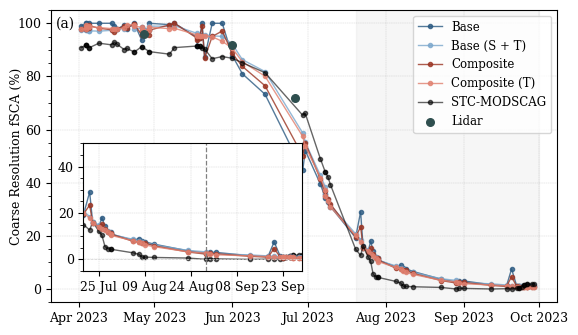

In [79]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.lines import Line2D
import matplotlib.ticker as tck

# === Setup ===
n_total = 11
n_colors = 6
plt.rcParams['font.family'] = 'serif'
year = '2023'

# Custom colors
colors = ['#2a5981', '#7ba7cc', '#9a3422', '#e0806f']
dfs = [merged_1, merged_2, merged_3, merged_4]
names = ['Base', 'Base (S + T)', 'Composite', 'Composite (T)']
# Define date ranges
start_date = pd.to_datetime(f'{year}-04-01')
end_date = pd.to_datetime(f'{year}-09-30')
inset_start = pd.to_datetime(f'{year}-07-20')
inset_end = pd.to_datetime(f'{year}-10-01')
# Trim main MODIS data
trimmed_modis_df = modis_df[(modis_df['date'] >= start_date) & (modis_df['date'] <= end_date)]

# === Scaling for journal submission ===
scale = 7/12  # target width / current width
fig_width, fig_height = 5.9, 3.45

fs_label = 9 
fs_tick  = 9
fs_text  = 10
fs_legend = 8.5
ms_marker = 3
lw_line = 1
s_scatter = 30 

# === Main Figure ===
fig, ax = plt.subplots(figsize=(fig_width, fig_height))

# Main time series
for i, df in enumerate(dfs):
    trimmed_df = df[(df['date'] >= start_date) & (df['date'] <= end_date)]
    ax.plot(trimmed_df['date'], trimmed_df['fsca_ps'], label=names[i],
            marker='o', markersize=ms_marker, linestyle='-', linewidth=lw_line,
            color=colors[i], alpha=.8)

# MODIS
ax.plot(trimmed_modis_df['date'], trimmed_modis_df['fsca'], label='STC-MODSCAG',
        marker='o', markersize=ms_marker, linestyle='-', linewidth=lw_line,
        color='black', alpha=.6)

# ASO
ax.scatter(aso_merged_df_all['date'], aso_merged_df_all['fsca_aso'], label='Lidar',
           color='darkslategrey', s=s_scatter, zorder=10)

# === Inset ===
ax_inset = fig.add_axes([0.15, 0.2, 0.37, 0.37])

# Trim and plot inset datasets
trimmed_modis_inset = modis_df[(modis_df['date'] >= inset_start) & (modis_df['date'] <= inset_end)].dropna(subset=['fsca'])
trimmed_aso_inset = aso_merged_df_all[(aso_merged_df_all['date'] >= inset_start) & (aso_merged_df_all['date'] <= inset_end)].dropna(subset=['fsca_aso'])

# Inset plots
ax_inset.plot(trimmed_aso_inset['date'], trimmed_aso_inset['fsca_aso'], label='Lidar',
              color='darkslategrey', linewidth=lw_line)
ax_inset.plot(trimmed_modis_inset['date'], trimmed_modis_inset['fsca'], label='STC-MODSCAG',
              marker='o', markersize=ms_marker, linewidth=lw_line, color='black', alpha=0.6)

for i, df in enumerate(dfs):
    trimmed_df = df[(df['date'] >= inset_start) & (df['date'] <= inset_end)].dropna(subset=['fsca_ps'])
    ax_inset.plot(trimmed_df['date'], trimmed_df['fsca_ps'], label=names[i],
                  marker='o', markersize=ms_marker, linestyle='-', linewidth=lw_line,
                  color=colors[i], alpha=0.8)

# Inset styling
ax_inset.axvline(pd.to_datetime(f'{year}-06-27'), color='gray', linestyle='--', linewidth=0.9)
ax_inset.axvline(pd.to_datetime(f'{year}-08-29'), color='gray', linestyle='--', linewidth=0.9)
ax_inset.axhline(0, color='lightgray', linestyle='--', linewidth=0.5)

ax_inset.set_ylim(-5, 50)
ax_inset.xaxis.set_major_locator(mdates.DayLocator(interval=15))
ax_inset.xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))
ax_inset.yaxis.set_minor_locator(tck.AutoMinorLocator())
ax_inset.grid(True, which='major', linestyle='--', linewidth=0.3, color='gray', alpha=0.4)
ax_inset.tick_params(axis='x', labelsize=fs_tick)
ax_inset.tick_params(axis='y', labelsize=fs_tick)
# Get exact min/max of the dates for the inset
x_min = min(trimmed_modis_inset['date'].min(),
            trimmed_aso_inset['date'].min(),
            min([df[(df['date'] >= inset_start) & (df['date'] <= inset_end)]['date'].min() for df in dfs]))

x_max = max(trimmed_modis_inset['date'].max(),
            trimmed_aso_inset['date'].max(),
            max([df[(df['date'] >= inset_start) & (df['date'] <= inset_end)]['date'].max() for df in dfs]))

ax_inset.set_xlim(x_min, x_max)
# === Main Plot Styling ===
ax.set_xlim(pd.to_datetime(f'{year}-03-21'), pd.to_datetime(f'{year}-10-08'))
ax.set_ylim(-5, 105)
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.yaxis.set_minor_locator(tck.AutoMinorLocator())
ax.grid(True, which='major', linestyle='--', linewidth=0.3, color='gray', alpha=0.4)
ax.tick_params(axis='x', labelsize=fs_tick)
ax.tick_params(axis='y', labelsize=fs_tick)
ax.axvspan(pd.to_datetime(inset_start), pd.to_datetime(inset_end), color='lightgray', alpha=0.2)
ax.set_ylabel('Coarse Resolution fSCA (%)', fontsize=fs_label, labelpad=-4)
ax.text(0.01, 0.94, '(a)', transform=ax.transAxes, fontsize=fs_text)


# === Legend ===
custom_lines = [Line2D([0], [0], color=colors[i], lw=lw_line) for i in range(len(names))] + [
    Line2D([0], [0], marker='o', color='darkslategrey', lw=0, markersize=2, label='ASO')]
ax.legend(custom_lines, names + ['ASO'], loc='lower left', fontsize=fs_legend)
ax.legend(loc='upper right', fontsize=fs_legend)
# === Finalize ===
plt.tight_layout()
# plt.show()# Save PDF for submission
plt.savefig('/home/etboud/projects/figures/Figure_S5.png', format='png',dpi = 1000,bbox_inches='tight')

### Timeseries figure without inset

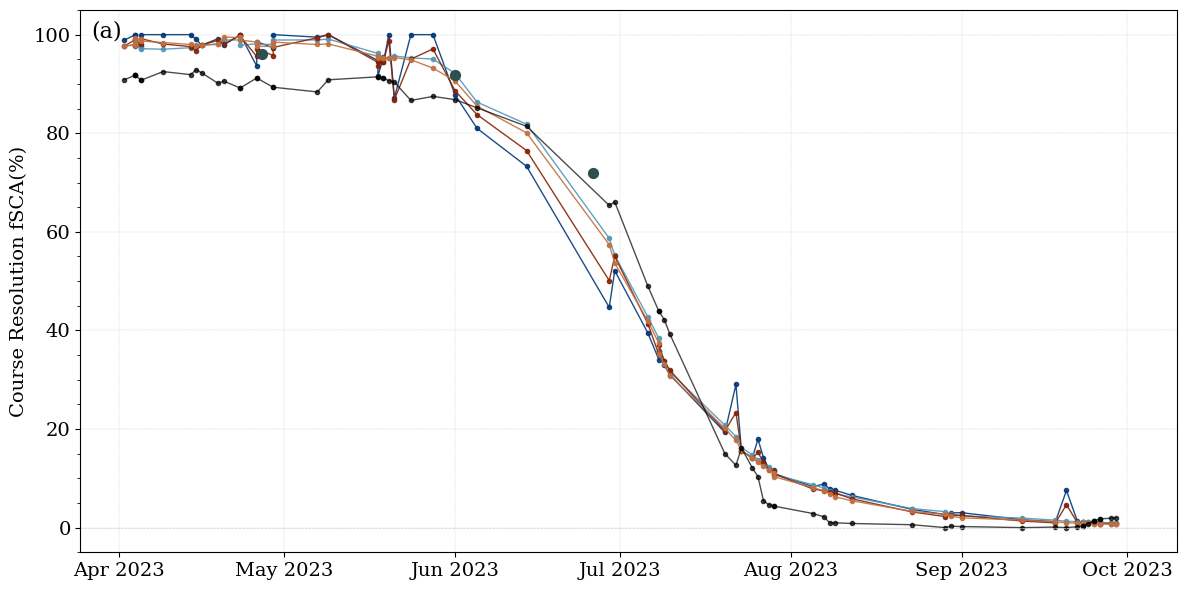

In [9]:
import matplotlib.ticker as tck
n_total = 11
n_colors = 6  # Number of distinct colors needed
plt.rcParams['font.family'] = 'serif'
# Generate evenly spaced indices for the colormap
# color_indices = np.linspace(0.2, .9, n_colors)
year = '2023'
# color_indices = np.linspace(0.2, .9, n_colors)
# Get colors from the colormap at these indices
# colors = [cmc.managua(idx) for idx in color_indices]
# Manually select values toward the edges, but not at 0 or 1
color_indices = [0.1, 0.3, 0.9, .75]  # bias toward ends, skip center

# Get colors from the colormap
colors = [cmc.vik(idx) for idx in color_indices]
# Ensure all required dataframes are defined
dfs = [merged_1, merged_2, merged_3, merged_4]  # Replace with actual dataframes if available
names = ['Base', 'Base PP (S + T)', 'Composite', 'Composite PP (T)']
# only plot that water year 
start_date = pd.to_datetime(f'{year}-04-01')
end_date = pd.to_datetime(f'{year}-09-30')
# trim modis_df to the same date range
trimmed_modis_df = modis_df[(modis_df['date'] >= start_date) & (modis_df['date'] <= end_date)]

fig, ax = plt.subplots(figsize=(12, 6))
for i, df in enumerate(dfs):
    trimmed_df = df[(df['date'] >= start_date) & (df['date'] <= end_date)]
    ax.plot(trimmed_df['date'], trimmed_df['fsca_ps'], label=names[i], marker='o', markersize=3, linestyle='-', linewidth=1, color=colors[i], alpha = .9)
ax.plot(trimmed_modis_df['date'], trimmed_modis_df['fsca'], label='STC-MODSCAG', marker='o', markersize=3, linestyle='-', linewidth=1, color='black', alpha =.7)
ax.scatter(aso_merged_df_all['date'], aso_merged_df_all['fsca_aso'], label='ASO', color='darkslategrey', s=50,zorder=10)
ax.axhline(0, color='lightgray', linestyle='--', linewidth=0.5)

ax.set_xlim(pd.to_datetime(f'{year}-03-25'), pd.to_datetime(f'{year}-10-10'))
ax.tick_params(axis='x', labelsize=14)
ax.tick_params(axis='y', labelsize=14)
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
# # mark inset on main plot
# ax.axvspan(pd.to_datetime(f'{year}-05-15'), pd.to_datetime(f'{year}-08-01'), color='lightgray', alpha=0.2)
# ax.axvline(pd.to_datetime(f'{year}-08-29'), color='gray', linestyle='--', linewidth=0.9)
# ax.axvline(pd.to_datetime(f'{year}-07-30'), color='gray', linestyle='--', linewidth=0.9)

# # custom legend with names
# custom_lines = [Line2D([0], [0], color=colors[i], lw=2) for i in range(min(len(colors), len(names)))] + [
#                 Line2D([0], [0], marker='o', color='darkslategrey', label='ASO')]
# ax.legend(custom_lines, names[:len(custom_lines)], loc='upper right', fontsize=14)
ax.grid(True, which='major', linestyle='--', linewidth=0.3, color='gray', alpha=0.4)
ax.yaxis.set_minor_locator(tck.AutoMinorLocator())
# ax.legend(loc='lower left', fontsize=16)
ax.set_ylabel('Course Resolution fSCA(%)', fontsize=14)
# add text
ax.text(0.01, 0.95, f'(a)', transform=ax.transAxes, fontsize=16)
ax.set_ylim(-5, 105)
#save as png
plt.tight_layout()
# plt.savefig(f'/home/etboud/projects/figures/BUDD_fsca_timeseries_{year}_flowchart_fig2.png', dpi=400, bbox_inches='tight')

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import cmcrameri.cm as cmc
import matplotlib.colors as mcolors
import matplotlib.cm as cm
from mpl_toolkits.axes_grid1 import ImageGrid
from matplotlib.lines import Line2D
# If 'date' is not in datetime format, convert it
# planet_fsca_df["date"] = pd.to_datetime(planet_fsca_df["date"], errors="coerce")

# Define seasonal start and end in MM-DD format (no year!)
season_start = (4, 1)  # April 1
season_end = (9, 29)   # September 29

# Function to convert a date to "day of season" index
def day_of_season(date):
    # Treat all dates as year-agnostic, use a reference leap-safe year
    dummy_year = 2001
    start = pd.Timestamp(f"{dummy_year}-{season_start[0]:02d}-{season_start[1]:02d}")
    current = pd.Timestamp(f"{dummy_year}-{date.month:02d}-{date.day:02d}")
    return (current - start).days

# Apply the function to both dataframes
merged_2022['day_of_season'] = merged_2022['date'].apply(day_of_season)
merged_2023['day_of_season'] = merged_2023['date'].apply(day_of_season)
aso_merged_2022['day_of_season'] = aso_merged_2022['date'].apply(day_of_season)
aso_merged_2023['day_of_season'] = aso_merged_2023['date'].apply(day_of_season)

# Set up shared color scale
vmin, vmax = 0, day_of_season(pd.Timestamp(f"2001-{season_end[0]:02d}-{season_end[1]:02d}"))
norm = mcolors.Normalize(vmin=vmin, vmax=vmax)
cmap = cmc.batlow

# Generate colors
colors_2022 = cmap(norm(merged_2022['day_of_season']))
colors_2023 = cmap(norm(merged_2023['day_of_season']))
colors_aso_2022 = cmap(norm(aso_merged_2022['day_of_season']))
colors_aso_2023 = cmap(norm(aso_merged_2023['day_of_season']))

plt.rcParams['font.family'] = 'serif'
fig = plt.figure(figsize=(12, 12))

ax = ImageGrid(fig, 111,
                nrows_ncols=(1, 2),
                axes_pad=.1,
                cbar_location="right",
                cbar_mode="single",
                cbar_size="5%",
                cbar_pad=0.05
                )

ax[0].scatter(
    merged_2022['fsca_modis'],
    merged_2022['fsca_ps'],
    c=colors_2022,

    alpha=0.7,
    edgecolor='k',
    linewidth=0.2
)
# insert text 
ax[0].text(0.8, 0.055, '2022', transform=ax[0].transAxes, fontsize=14, fontweight='bold')
# add inset zoomed in
# axins0 = ax[0].inset_axes([0.07, 0.56, 0.4, 0.4])  # [x, y, width, height]
# axins0.scatter(
#     merged_2022['fsca_modis'],
#     merged_2022['fsca_ps'],
#     c=colors_2022,
#     alpha=0.7,
#     edgecolor='k',
#     linewidth=0.2
# )
twin1 = ax[0].scatter(aso_merged_2022['fsca_modis'], 
                    aso_merged_2022['fsca_aso'], 
                    marker = 'd',s = 130,color=colors_aso_2022,
                    alpha=0.8, edgecolor='k', linewidth=0.2, label = 'Lidar')
# # Set limits for the inset
# axins0.set_xlim(-1, 35)
# axins0.set_ylim(-1, 35)
# axins0.set_xticks([0, 10,20,30])
# axins0.set_yticks([0, 10,20,30])
# # Add grid to the inset
# axins0.grid(True)
# # mark where inset ins on main plot
# x1, x2, y1, y2 = 0, 10, 0, 10
# ax[0].indicate_inset_zoom(axins0, edgecolor="black", alpha=0.5)
# # draw lines on inset
# axins0.plot([0, 35], [0, 35], color='black', alpha = .5, linestyle='--')
# # mark correspiing region on main plot and draw 2 lines linking two axes)


ax[1].scatter(
    merged_2023['fsca_modis'],
    merged_2023['fsca_ps'],
    c=colors_2023,

    alpha=0.7,
    edgecolor='k',
    linewidth=0.2
)
# insert text 
ax[1].text(0.8, 0.055, '2023', transform=ax[1].transAxes, fontsize=14, fontweight='bold')
# # add inset zoomed in
# axins1= ax[1].inset_axes([0.07, 0.56, 0.4, 0.4])  # [x, y, width, height]
# axins1.scatter(
#     merged_2023['fsca_modis'],
#     merged_2023['fsca_ps'],
#     c=colors_2023,
#     alpha=0.7,
#     edgecolor='k',
#     linewidth=0.2
# )


twin2 = ax[1].scatter(aso_merged_2023['fsca_modis'], 
                    aso_merged_2023['fsca_aso'], 
                    marker = 'd',s = 130,color=colors_aso_2023,
                    alpha=0.8, edgecolor='k', linewidth=0.2, label = 'Lidar')
ax[1].set_ylim(-5, 105)

# # Set limits for the inset
# axins1.set_xlim(-1, 35)
# axins1.set_ylim(-1, 35)
# axins1.set_xticks([0, 10,20,30])
# axins1.set_yticks([0, 10,20,30])
# # Add grid to the inset
# axins1.grid(True)
# # mark where inset ins on main plot
# x1, x2, y1, y2 = 0, 10, 0, 10
# ax[1].indicate_inset_zoom(axins1, edgecolor="black", alpha=0.5)
# # draw lines on inset
# axins1.plot([0, 35], [0, 35], color='black', alpha = .5, linestyle='--')
# # mark correspiing region on main plot and draw 2 lines linking two axes)




# # Add colorbar to show date mapping
# sm = cm.ScalarMappable(cmap=cmc.batlow, norm=norm)
# sm.set_array([])
# # cbar = plt.colorbar(sm, ax.cbar_axes[0])
#cbar.set_label('Date')
# add 1 to 1 line
x = np.linspace(0, 100, 100)
y = x
for axis in [ax[0], ax[1]]:
    axis.plot(x, y, color='black', alpha=0.5, linestyle='--', label='1:1 Line')
    # Labeling
    axis.set_xlabel('STC-MODSCAG Basin fSCA (%)')
    axis.set_ylabel('Fine Product Basin fSCA (%)')


# Create ScalarMappable for the colorbar
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])  # Required for ScalarMappable

# Add one colorbar for both plots
cbar = fig.colorbar(sm, cax=ax.cbar_axes[0], orientation='vertical')

# Set MM-DD labels for selected ticks
tick_days = [0, 75, 181]  # Approx. Apr 1, mid-June, Sept 29
tick_labels = ['04-01', '06-15', '09-29']
cbar.set_ticks(tick_days)
cbar.set_ticklabels(tick_labels)

for axis in ax:
    axis.grid(True)
    
    
# Custom legend handles with black color
custom_handles = [
    Line2D([0], [0], marker='o', markeredgecolor='k', color='white', alpha=.7, linestyle='None', label='Composite PP (T)'),
    Line2D([0], [0], marker='d', markeredgecolor='k', color='white', alpha=.7, linestyle='None', label='Lidar'),
    Line2D([0], [0], color='black', linestyle='--', alpha=.7, label='1:1 Line')
]
# Now pass them to the main legend
# Add the legend to the first axis in the grid
ax[0].legend(custom_handles, [h.get_label() for h in custom_handles], bbox_to_anchor=(1.4, 1.08), ncol=3, fontsize=10, frameon=False)

    
plt.tight_layout()
plt.show()

In [19]:
for df, _ in dfs:
    print(f"Before filtering: {len(df)} rows")
    df = df[(df['fsca_ps'] != 0) & (df['fsca_modis'] != 0)]
    print(f"After filtering: {len(df)} rows")


Before filtering: 265 rows
After filtering: 144 rows
Before filtering: 265 rows
After filtering: 144 rows
Before filtering: 265 rows
After filtering: 144 rows
Before filtering: 265 rows
After filtering: 144 rows


In [28]:
dfss = [merged_1, merged_2, merged_3, merged_4]

for df in dfss:


    
    diff = (df['fsca_ps'] - df['fsca_modis'])
    # mean and standard deviation
    mean_diff = diff.mean()
    std_diff = diff.std()
    print(f"Mean difference: {mean_diff:.2f}%, Std Dev: {std_diff:.2f}%")

Mean difference: 4.22%, Std Dev: 8.07%
Mean difference: 1.58%, Std Dev: 3.82%
Mean difference: 2.61%, Std Dev: 4.95%
Mean difference: 2.03%, Std Dev: 3.73%


/tmp/ipykernel_1171165/3333942822.py:107: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


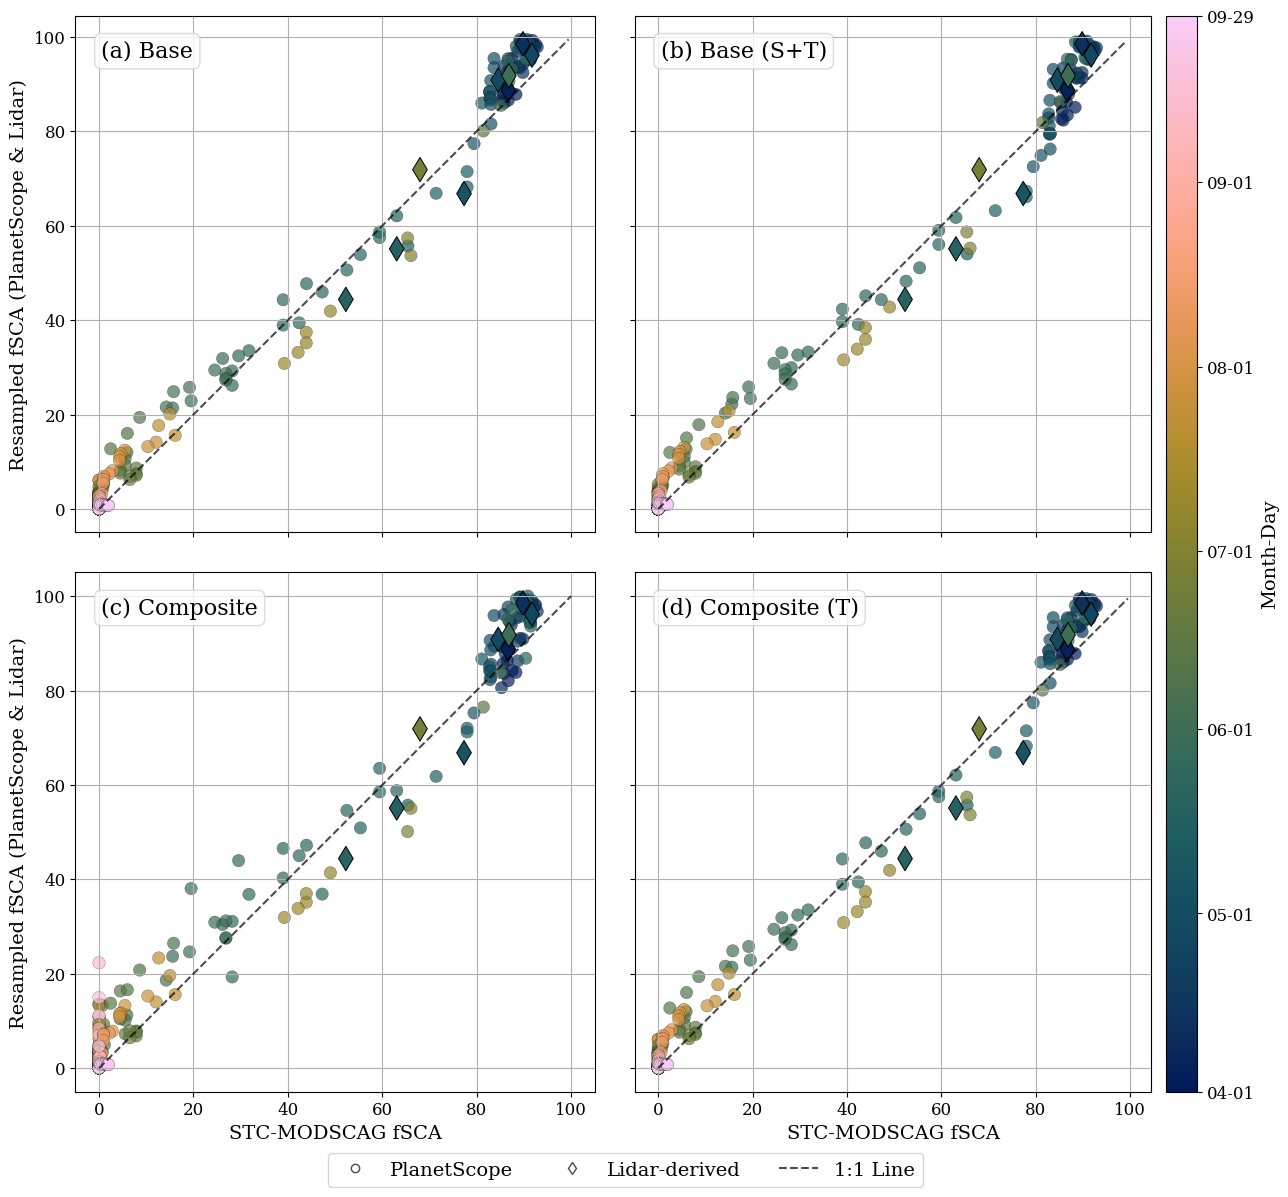

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.lines import Line2D
from mpl_toolkits.axes_grid1 import ImageGrid
import cmcrameri.cm as cmc

# Assume dfs = [(merged_1, aso_merged_1), (merged_2, aso_merged_2), ...]
dfs = [(merged_1, aso_merged), (merged_2, aso_merged), 
       (merged_3, aso_merged), (merged_4, aso_merged)]
model_name = ['(a) Base', '(b) Base (S+T)', '(c) Composite', '(d) Composite (T)']
# Define season range (year-agnostic)
season_start = (4, 1)  # April 1
season_end = (9, 29)   # September 29

def day_of_season(date):
    dummy_year = 2001
    start = pd.Timestamp(f"{dummy_year}-{season_start[0]:02d}-{season_start[1]:02d}")
    current = pd.Timestamp(f"{dummy_year}-{date.month:02d}-{date.day:02d}")
    return (current - start).days

# Compute max days for normalization
vmin, vmax = 0, day_of_season(pd.Timestamp(f"2001-{season_end[0]:02d}-{season_end[1]:02d}"))
norm = mcolors.Normalize(vmin=vmin, vmax=vmax)
cmap = cmc.batlow

plt.rcParams['font.family'] = 'serif'
fig = plt.figure(figsize=(16, 12))

# Set up 2x2 grid
ax = ImageGrid(fig, 111,
                nrows_ncols=(2, 2),
                axes_pad=.4,
                cbar_location="right",
                cbar_mode="single",
                cbar_size="3%",
                cbar_pad=0.15,
                label_mode = 'L'
              )

for i, (merged_df, aso_df) in enumerate(dfs):
    
    # Calculate day_of_season for ps data
    merged_df['day_of_season'] = merged_df['date'].apply(day_of_season)
    colors_ps = cmap(norm(merged_df['day_of_season']))
    
    # Same for aso data
    aso_df['day_of_season'] = aso_df['date'].apply(day_of_season)
    colors_aso = cmap(norm(aso_df['day_of_season']))

    # Scatter plot for ps
    ax[i].scatter(
        merged_df['fsca_modis'],
        merged_df['fsca_ps'],
        c=colors_ps,
        alpha=0.7,
        edgecolor='k',
        linewidth=0.2,
        s=80
    )

    # Scatter plot for aso
    ax[i].scatter(
        aso_df['fsca_modis'], 
        aso_df['fsca_aso'], 
        marker='d', s=155, c=colors_aso,
        alpha=1, edgecolor='k', linewidth=0.7, label='Lidar'
    )
    
    # 1:1 line
    min_val = min(merged_df['fsca_modis'].min(), merged_df['fsca_ps'].min(),
                  aso_df['fsca_aso'].min(), aso_df['fsca_modis'].min())
    max_val = max(merged_df['fsca_modis'].max(), merged_df['fsca_ps'].max(),
                  aso_df['fsca_aso'].max(), aso_df['fsca_modis'].max())
    ax[i].plot([min_val, max_val], [min_val, max_val], 'k--', alpha=0.7)
    ax[i].grid(True)
    
    # ax[i].set_title(model_name[i], fontsize=15)
    ax[i].set_xlabel("STC-MODSCAG fSCA", fontsize=14)
    ax[i].set_ylabel("Resampled fSCA (PlanetScope & Lidar)", fontsize = 14)
    ax[i].tick_params(axis='x', labelsize=12)
    ax[i].tick_params(axis='y', labelsize=12)
    # add text box with model name
    ax[i].text(0.05, 0.92, model_name[i], transform=ax[i].transAxes, fontsize=16, bbox=dict(boxstyle = 'round',facecolor='white', alpha=0.8, edgecolor='lightgrey'))
# Create ScalarMappable for shared colorbar
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, cax=ax.cbar_axes[0], orientation='vertical')

# Set meaningful colorbar ticks
tick_days = [0, 30, 61,91,122,153,181]
tick_labels = ['04-01', '05-01','06-01', '07-01','08-01','09-01','09-29']
cbar.set_ticks(tick_days)
cbar.set_ticklabels(tick_labels, fontsize = 12)
cbar.set_label("Month-Day", fontsize=14)

# Add shared custom legend
custom_handles = [
    Line2D([0], [0], marker='o', markeredgecolor='k', color='white', alpha=.7, linestyle='None', label='PlanetScope'),
    Line2D([0], [0], marker='d', markeredgecolor='k', color='white', alpha=.7, linestyle='None', label='Lidar-derived'),
    Line2D([0], [0], color='black', linestyle='--', alpha=.7, label='1:1 Line')
]
# Only add legend to first subplot
ax[2].legend(custom_handles, [h.get_label() for h in custom_handles], bbox_to_anchor=(1.65, -0.1), ncol=3, fontsize=14, frameon=True)

plt.tight_layout()

# save plot dpi 400
# plt.savefig(f'/home/etboud/projects/figures/Figure_5', dpi=400, bbox_inches='tight')
# plt.savefig(f'/home/etboud/projects/figures/Figure_5.pdf', format = 'pdf', bbox_inches='tight')

/tmp/ipykernel_1274292/876328195.py:110: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


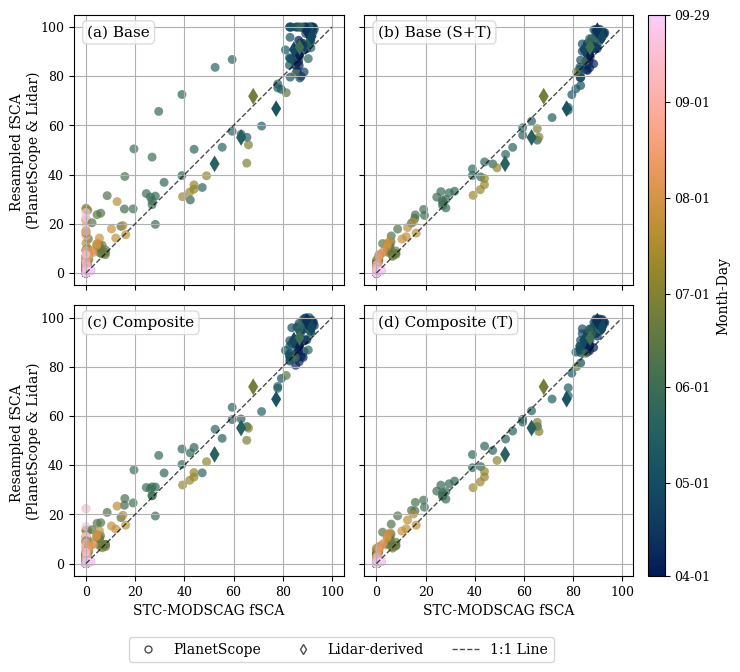

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.lines import Line2D
from mpl_toolkits.axes_grid1 import ImageGrid
import cmcrameri.cm as cmc

# Example: your data tuples
dfs = [(merged_1, aso_merged), (merged_2, aso_merged), 
       (merged_3, aso_merged), (merged_4, aso_merged)]
model_name = ['(a) Base', '(b) Base (S+T)', '(c) Composite', '(d) Composite (T)']

# Define season range (year-agnostic)
season_start = (4, 1)
season_end = (9, 29)

def day_of_season(date):
    dummy_year = 2001
    start = pd.Timestamp(f"{dummy_year}-{season_start[0]:02d}-{season_start[1]:02d}")
    current = pd.Timestamp(f"{dummy_year}-{date.month:02d}-{date.day:02d}")
    return (current - start).days

# Compute max days for normalization
vmin, vmax = 0, day_of_season(pd.Timestamp(f"2001-{season_end[0]:02d}-{season_end[1]:02d}"))
norm = mcolors.Normalize(vmin=vmin, vmax=vmax)
cmap = cmc.batlow

# === Scaled figure for double-column (Elsevier) ===
plt.rcParams['font.family'] = 'serif'
fig = plt.figure(figsize=(7.5, 7.5))  # double-column width

ax = ImageGrid(fig, 111,
               nrows_ncols=(2, 2),
               axes_pad=0.2,
               cbar_location="right",
               cbar_mode="single",
               cbar_size="3%",
               cbar_pad=0.15,
               label_mode='L')

# Reduce marker sizes and line widths for smaller figure
marker_ps_size = 40
marker_aso_size = 70
line_width = 1.0
edge_width_ps = 0.05
edge_width_aso = 0.05
font_size_label = 10
font_size_tick = 9
font_size_textbox = 11

for i, (merged_df, aso_df) in enumerate(dfs):
    merged_df['day_of_season'] = merged_df['date'].apply(day_of_season)
    colors_ps = cmap(norm(merged_df['day_of_season']))
    aso_df['day_of_season'] = aso_df['date'].apply(day_of_season)
    colors_aso = cmap(norm(aso_df['day_of_season']))
    
    ax[i].scatter(
        merged_df['fsca_modis'],
        merged_df['fsca_ps'],
        c=colors_ps,
        alpha=0.7,
        edgecolor='darkslategrey',
        linewidth=edge_width_ps,
        s=marker_ps_size
    )
    
    ax[i].scatter(
        aso_df['fsca_modis'], 
        aso_df['fsca_aso'], 
        marker='d', s=marker_aso_size, c=colors_aso,
        alpha=1, edgecolor='k', linewidth=edge_width_aso
    )
    
    # 1:1 line
    min_val = min(merged_df['fsca_modis'].min(), merged_df['fsca_ps'].min(),
                  aso_df['fsca_aso'].min(), aso_df['fsca_modis'].min())
    max_val = max(merged_df['fsca_modis'].max(), merged_df['fsca_ps'].max(),
                  aso_df['fsca_aso'].max(), aso_df['fsca_modis'].max())
    ax[i].plot([min_val, max_val], [min_val, max_val], 'k--', alpha=0.7, linewidth=line_width)
    
    ax[i].grid(True)
    ax[i].set_xlabel("STC-MODSCAG fSCA", fontsize=font_size_label)
    ax[i].set_ylabel("Resampled fSCA \n(PlanetScope & Lidar)", fontsize=font_size_label, labelpad=-.5)
    ax[i].tick_params(axis='x', labelsize=font_size_tick)
    ax[i].tick_params(axis='y', labelsize=font_size_tick)
    ax[i].text(0.05, 0.92, model_name[i], transform=ax[i].transAxes, 
               fontsize=font_size_textbox,
               bbox=dict(boxstyle='round', facecolor='white', alpha=0.8, edgecolor='lightgrey'))

# Shared colorbar
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, cax=ax.cbar_axes[0], orientation='vertical')
tick_days = [0, 30, 61, 91, 122, 153, 181]
tick_labels = ['04-01', '05-01', '06-01', '07-01', '08-01', '09-01', '09-29']
cbar.set_ticks(tick_days)
cbar.set_ticklabels(tick_labels, fontsize=font_size_tick)
cbar.set_label("Month-Day", fontsize=font_size_label)

# Shared legend
custom_handles = [
    Line2D([0], [0], marker='o', markeredgecolor='k', color='white', alpha=.7, linestyle='None', label='PlanetScope', markersize=5),
    Line2D([0], [0], marker='d', markeredgecolor='k', color='white', alpha=.7, linestyle='None', label='Lidar-derived', markersize=5),
    Line2D([0], [0], color='black', linestyle='--', alpha=.7, label='1:1 Line', linewidth=1)
]
ax[2].legend(custom_handles, [h.get_label() for h in custom_handles],
             bbox_to_anchor=(1.8, -0.2), ncol=3, fontsize=font_size_label, frameon=True)

plt.tight_layout()
plt.savefig('/home/etboud/projects/figures/Figure_5_bigger.pdf', format='pdf', bbox_inches='tight')
# plt.show()

In [ ]:
for df in [merged_1, merged_2, merged_3, merged_4]:
    df['residual'] = df['fsca_ps'] - df['fsca_modis']
    rmse = np.sqrt(np.mean(df['residual']**2))
    n = len(df)
    bias = np.mean(df['residual'])
    corr = df[['fsca_modis', 'fsca_ps']].corr().iloc[0, 1]
    print(f'RMSE: {rmse:.2f}, Bias: {bias:.2f}, n: {n}, Corr: {corr:.2f}')

In [ ]:
def concordance_correlation_coefficient(y_true, y_pred):
    """
    Calculate the Concordance Correlation Coefficient (CCC)
    """
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    
    mean_true = np.mean(y_true)
    mean_pred = np.mean(y_pred)
    
    var_true = np.var(y_true, ddof=1)
    var_pred = np.var(y_pred, ddof=1)
    
    covariance = np.cov(y_true, y_pred, ddof=1)[0, 1]
    
    numerator = 2 * covariance
    denominator = var_true + var_pred + (mean_true - mean_pred)**2
    
    ccc = numerator / denominator
    return ccc

In [ ]:
for df in [merged_1, merged_2, merged_3, merged_4]:
    # break into fsca levels
    # 40 %
    df_lowest = df['fsca_ps']<10
    df_low = (df['fsca_ps']>=10) & (df['fsca_ps']<35)
    df_mid = (df['fsca_ps']>=35) & (df['fsca_ps']<80)
    df_high = df['fsca_ps']>=80
    for level, label in zip([df_lowest, df_low, df_mid, df_high], ['<10%','10-35%', '35-80%', '>80%']):
        ccc = concordance_correlation_coefficient(df.loc[level, 'fsca_modis'], df.loc[level, 'fsca_ps'])
        print(f'CCC for {label}: {ccc:.4f}')
    ccc = concordance_correlation_coefficient(df['fsca_modis'], df['fsca_ps'])
    print(f'CCC: {ccc:.4f}')

In [55]:
# determine date of snow disappearance in basin
for year in [2020,2022,2023]:
    for df in [merged_1, merged_2, merged_3, merged_4]:
        df_year = df[df['date'].dt.year == year]
        # find first date where fsca_ps is 0
        first_zero_date = df_year[df_year['fsca_modis'] == 0]['date'].min()
        # the corresponding fsca_ps for the date
        first_zero_fsca_ps = df_year[df_year['date'] == first_zero_date]['fsca_ps'].values
        if len(first_zero_fsca_ps) > 0:
            first_zero_fsca_ps = first_zero_fsca_ps[0]
        else:
            first_zero_fsca_ps = np.nan
        if pd.notna(first_zero_date):
            print(f'First snow disappearance in {year}: {first_zero_date.strftime("%Y-%m-%d")}')
            print(f'Corresponding fsca_ps: {first_zero_fsca_ps:.2f}%')
        else:
            print(f'No snow disappearance in {year}')


First snow disappearance in 2020: 2020-06-23
Corresponding fsca_ps: 4.02%
First snow disappearance in 2020: 2020-06-23
Corresponding fsca_ps: 3.92%
First snow disappearance in 2020: 2020-06-23
Corresponding fsca_ps: 3.50%
First snow disappearance in 2020: 2020-06-23
Corresponding fsca_ps: 3.62%
First snow disappearance in 2022: 2022-06-27
Corresponding fsca_ps: 4.50%
First snow disappearance in 2022: 2022-06-27
Corresponding fsca_ps: 5.20%
First snow disappearance in 2022: 2022-06-27
Corresponding fsca_ps: 4.07%
First snow disappearance in 2022: 2022-06-27
Corresponding fsca_ps: 4.81%
First snow disappearance in 2023: 2023-08-29
Corresponding fsca_ps: 2.65%
First snow disappearance in 2023: 2023-08-29
Corresponding fsca_ps: 3.24%
First snow disappearance in 2023: 2023-08-29
Corresponding fsca_ps: 2.24%
First snow disappearance in 2023: 2023-08-29
Corresponding fsca_ps: 2.70%


In [56]:
basin_mask = rxr.open_rasterio('/home/etboud/projects/data/masks/BUDD_mask.tif').squeeze()


In [57]:
# count ones in basin mask
n_ones = np.sum(basin_mask.values == 1)

In [64]:
n_ones*9*.03

227293.56